# BioSample trace-back evaluation

This notebook explains how extracted BioSample field values are traced back to their source records -- the matching cascade's tiers and what each one means -- then evaluates how well those values are actually supported by their source records: concrete examples of each matching tier, the unresolved residual reviewed against an independent read, the LLM evidence tier's precision and recall, and the pipeline-level limitations that no amount of matching-tier work can fix. For how well the cascade performs in aggregate across the crate's 9 target fields, and how those curated fields are represented in the original raw metadata across the dataset and over time, see `biosample_trace_back_analysis.ipynb`.

In [1]:
# TABLE OF CONTENTS
import sys

sys.path.insert(0, "../src")
from notebook_utils import table_of_contents

table_of_contents("biosample_trace_back_evaluation.ipynb")

### Table of contents


[BioSample trace-back evaluation](#BioSample-trace-back-evaluation)
- [Setup](#Setup)
- [Pipeline and dataset](#Pipeline-and-dataset)
- [How extracted values were traced back to the source record](#How-extracted-values-were-traced-back-to-the-source-record)
  - [What each tier means](#What-each-tier-means)
  - [Examples of each matching method](#Examples-of-each-matching-method)
  - [Unresolved values](#Unresolved-values)
    - [1. Found by both, same field](#1.-Found-by-both,-same-field)
    - [2. Qwen3-8B missed it](#2.-Qwen3-8B-missed-it)
    - [3. Qwen3-8B claimed evidence that doesn't hold up](#3.-Qwen3-8B-claimed-evidence-that-doesn't-hold-up)
    - [4. Found by both, different fields](#4.-Found-by-both,-different-fields)
    - [5. Not found by either](#5.-Not-found-by-either)
  - [Why deterministic matching missed these patterns](#Why-deterministic-matching-missed-these-patterns)
  - [LLM evidence review](#LLM-evidence-review)
- [Appendix: pipeline limitations](#Appendix:-pipeline-limitations)
  - [Ontology mapper accepts a coincidental short-symbol match instead of returning no match](#Ontology-mapper-accepts-a-coincidental-short-symbol-match-instead-of-returning-no-match)
  - [Correct extraction, wrong nearby term](#Correct-extraction,-wrong-nearby-term)
  - [Negation swallowed into a confidently-named, wrong compound](#Negation-swallowed-into-a-confidently-named,-wrong-compound)
  - [General fabrication rate, projected onto the full crate](#General-fabrication-rate,-projected-onto-the-full-crate)

## Setup

In [2]:
# IMPORTS
import json
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from bs_entries import (
    MATCH_STRATEGIES,
    bs_record_table,
    find_bs_entry_in_files,
    get_accession,
    iter_bs_entries,
    matches_display_table,
    scan_accessions,
    verify_extracted_against_raw,
    verify_extracted_against_raw_rows,
)
from notebook_utils import display_with_nested_tables, md, table_covers_json
from ontology import build_field_ontology_indexes
from paths import (
    CRATE_CONFIG_DIR,
    CRATE_INPUTS_DIR,
    CRATE_ONTOLOGY_DIR,
    CRATE_RESULTS_DIR,
    INDEPENDENT_REVIEW_MODEL_COMPARISON_200_PARQUET,
    LLM_EVIDENCE_QWEN3_8B_JSONLS,
    LLM_EVIDENCE_QWEN3_32B_JSONLS,
    QWEN_INDEPENDENT_REVIEW_200_PARQUET,
    RUN_INDEX_TSV,
    TRACE_BACK_FULL_PARQUET,
)
from select_results import curated_entry_table, find_entry, load_select_result

/workspace/BH26/BH26_BioSample_curation/.conda_env/lib/python3.12/site-packages/torch/cuda/__init__.py:228: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
# THE FOUR CATEGORIES, AS A FILTER OVER run_index.tsv's `dataset` COLUMN
@dataclass(frozen=True)
class Category:
    name: str
    organism: str
    technology: str
    dataset_prefix: str  # matches run_index.tsv's `dataset` column by startswith


CATEGORIES = [
    Category("DDBJ RNA-Seq", "Homo sapiens", "RNA-Seq", "rnaseq_human"),
    Category("DDBJ RNA-Seq", "Mus musculus", "RNA-Seq", "rnaseq_mouse"),
    Category("ChIP-Atlas", "Homo sapiens", "ChIP-Atlas (hg38)", "chipatlas_hg38"),
    Category("ChIP-Atlas", "Mus musculus", "ChIP-Atlas (mm10)", "chipatlas_mm10"),
]

run_index = pd.read_csv(RUN_INDEX_TSV, sep="\t")


def category_input_files(category: Category) -> list[Path]:
    datasets = sorted(run_index.loc[run_index["dataset"].str.startswith(category.dataset_prefix), "dataset"].unique())
    files: list[Path] = []
    for dataset in datasets:
        files.extend(sorted((CRATE_INPUTS_DIR / dataset).glob("bs_entries_*.jsonl")))
    return files

In [4]:
# ONTOLOGY INDEXES, BUILT ONCE PER SELECT CONFIG AND REUSED EVERYWHERE THEY'RE NEEDED
_ontology_indexes_cache: dict[str, dict] = {}


def get_ontology_indexes(select_config_filename: str) -> dict:
    if select_config_filename not in _ontology_indexes_cache:
        with (CRATE_CONFIG_DIR / select_config_filename).open() as f:
            select_config = json.load(f)
        fields = list(select_config.get("fields", {}).keys())
        _ontology_indexes_cache[select_config_filename] = build_field_ontology_indexes(select_config, CRATE_ONTOLOGY_DIR, fields)
    return _ontology_indexes_cache[select_config_filename]

## Pipeline and dataset

The pipeline takes BioSample records and produces curated field values such as disease, tissue, cell type, gene, and treatment. Each extracted value is checked against the same source record. A value is counted as traced when the record contains direct or curated supporting text; values without a match remain in the unresolved group for further review.

See `biosample_trace_back_analysis.ipynb` for how those curated fields are represented in the original raw metadata across the dataset and over time.

In [5]:
# LOAD THE TRACE-BACK CHECK'S FULL-CRATE RESULTS -- USED THROUGHOUT THIS NOTEBOOK
trace_back_full = pd.read_parquet(TRACE_BACK_FULL_PARQUET)

## How extracted values were traced back to the source record

Each extracted value is tested against its own source record through a fixed cascade, from strictest to most tolerant, moving to the next tier only when the current one fails to find it; for values every deterministic tier fails on, two LLM passes (a smaller model, then a larger one over whatever the smaller model still couldn't ground) get a turn before a value is finally left `not found`.

In [6]:
# LLM EVIDENCE TIER TALLIES: PER-TARGET-FIELD "llm"/"not found" COUNTS, ONE PER MODEL SIZE
def llm_pass_tallies_by_field(paths: list[Path]) -> pd.DataFrame:
    """Per-target-field counts of the LLM evidence tier's own verdict ("llm" if a proposed quote
    grounded, else "not found"), read directly from a pass's `--out` jsonl files. These carry the
    tier's OWN accounting of the residual it processed, which `trace_back_full` doesn't -- it only
    has the deterministic cascade's verdict, which is "not found" for every item an LLM pass sees.
    """
    counts: dict[str, dict[str, int]] = {}
    for path in paths:
        with path.open() as f:
            for line in f:
                record = json.loads(line)
                for row in record["rows"]:
                    field_counts = counts.setdefault(row["target_field"], {})
                    field_counts[row["strategy"]] = field_counts.get(row["strategy"], 0) + 1
    return pd.DataFrame(counts).T.fillna(0).astype(int).rename_axis("target_field")


qwen3_8b_tally = llm_pass_tallies_by_field(LLM_EVIDENCE_QWEN3_8B_JSONLS)
qwen3_32b_tally = llm_pass_tallies_by_field(LLM_EVIDENCE_QWEN3_32B_JSONLS)

LLM_TIERS = ["Qwen3-8B", "Qwen3-32B"]  # weakest first -- each tier only reprocesses the previous one's residual
STRATEGY_ORDER = [*MATCH_STRATEGIES, *LLM_TIERS, "not found"]


# COUNTS PER (TARGET FIELD, STRATEGY), DETERMINISTIC TIERS PLUS ONE COLUMN PER LLM_TIERS ENTRY
def strategy_breakdown(trace_back: pd.DataFrame, llm_tallies: list[pd.DataFrame]) -> pd.DataFrame:
    """`llm_tallies` are per-tier tallies (from `llm_pass_tallies_by_field`) in the same order as
    `LLM_TIERS`. Each tier's own "llm" count becomes its column; the last tier's own "not found" is
    the final residual -- together these account for every item exactly once, so nothing here
    double-counts or needs the deterministic cascade's own "not found" column at all.
    """
    counts = trace_back.groupby(["target_field", "strategy"]).size().unstack(fill_value=0)
    counts.columns.name = None
    counts = counts.reindex(columns=MATCH_STRATEGIES, fill_value=0)
    for tier, tally in zip(LLM_TIERS, llm_tallies):
        counts[tier] = tally["llm"].reindex(counts.index, fill_value=0)
    counts["not found"] = llm_tallies[-1]["not found"].reindex(counts.index, fill_value=0)
    counts["n_with_value"] = counts[STRATEGY_ORDER].sum(axis=1)
    counts["pct_found"] = 100 * (counts["n_with_value"] - counts["not found"]) / counts["n_with_value"]
    return counts.reset_index()


strategy_stats = strategy_breakdown(trace_back_full, [qwen3_8b_tally, qwen3_32b_tally])
strategy_stats.style.format({**{col: "{:,}" for col in [*STRATEGY_ORDER, "n_with_value"]}, "pct_found": "{:.1f}"})

,target_field,exact,case-insensitive,normalized,ontology synonym,bag of words,fuzzy,Qwen3-8B,Qwen3-32B,not found,n_with_value,pct_found
0,cell_line,"964,387","6,148","9,302","1,695",22,561,"1,244",204,"1,844","985,407",99.8
1,cell_type,"1,481,228","35,046","270,909","14,053",460,"4,330","43,088","16,402","25,220","1,890,736",98.7
2,chip_antigen,"347,358","4,166","1,396","1,184",3,139,"1,893","1,172","3,438","360,749",99.0
3,disease,"533,108","46,927","2,396","19,823",105,"1,049","20,393","4,181","7,269","635,251",98.9
4,drug,"745,717","14,430","3,430","7,517",209,525,"13,429","4,124","2,396","791,777",99.7
5,knockdown_gene,"53,761","1,642","20,143",642,2,26,"5,610","2,146","1,598","85,570",98.1
6,knockout_gene,"327,959","8,511","55,451","11,333",0,174,"23,144","3,766","14,495","444,833",96.7
7,overexpressed_gene,"164,884","4,876","20,262","1,696",56,48,"7,856","2,799","4,116","206,593",98.0
8,tissue,"2,460,412","199,081","19,402","18,166",44,"4,780","53,937","20,387","19,321","2,795,530",99.3


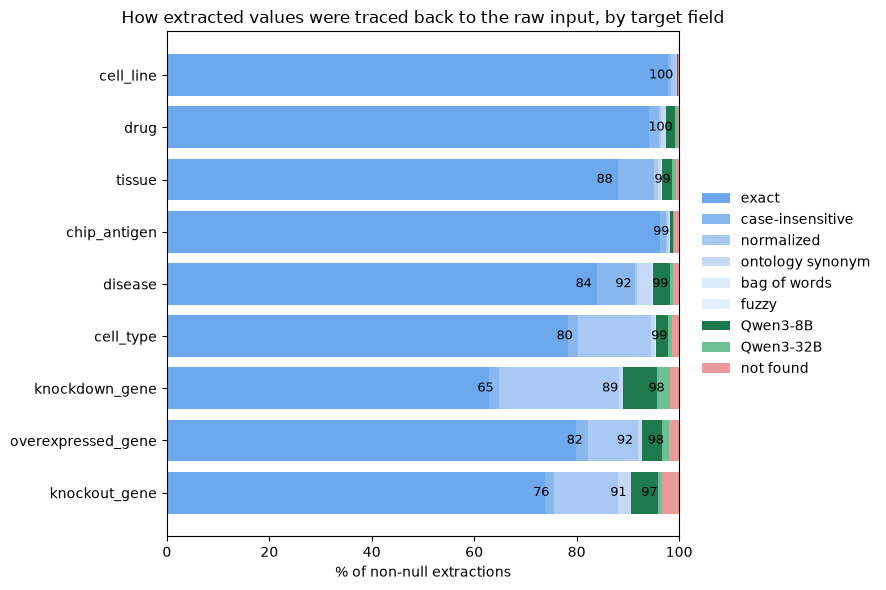

In [7]:
# STACKED PLOT: % OF EXTRACTIONS FOUND PER TIER, PER TARGET FIELD
def _select_label_positions(candidates: list[float], min_gap: float = 6.0) -> list[float]:
    """From candidate label positions (cumulative % boundaries on one bar), picks which to
    actually render as text: always the largest, then each next-largest only if it's at
    least `min_gap` percentage points from the last one kept -- otherwise two close
    boundaries produce overlapping, unreadable text (e.g. 58% and 59% back to back).
    """
    ordered = sorted(set(candidates), reverse=True)
    kept: list[float] = []
    for value in ordered:
        if not kept or (kept[-1] - value) >= min_gap:
            kept.append(value)
    return kept


def plot_strategy_breakdown(stats: pd.DataFrame, figsize: tuple[float, float] = (9, 6)) -> None:
    """Blue gradient sized to `MATCH_STRATEGIES`, green gradient sized to `LLM_TIERS`, red for "not
    found" -- built from those live lists rather than a hardcoded per-name dict, since this
    pipeline's tiers have changed before and a hardcoded dict would silently KeyError the moment a
    new one shows up in the data.
    """
    order = STRATEGY_ORDER
    blues = ["#6da7ec", "#89b8ef", "#a8c9f4", "#c6daf8", "#daeaf9", "#e3eefc"]
    greens = ["#1e7a4d", "#6dbf94", "#a8dfc0", "#d3f0e0"]
    colors = (
        dict(zip(MATCH_STRATEGIES, blues[: len(MATCH_STRATEGIES)]))
        | dict(zip(LLM_TIERS, greens[: len(LLM_TIERS)]))
        | {"not found": "#eb9a9a"}
    )

    fields = stats.sort_values("pct_found")["target_field"].tolist()
    pct = stats.set_index("target_field")
    pct = pct[order].div(pct["n_with_value"], axis=0) * 100
    pct = pct.loc[fields]

    fig, ax = plt.subplots(figsize=figsize)
    y_pos = list(range(len(fields)))
    left = pd.Series(0.0, index=pct.index)
    for strategy in order:
        ax.barh(y_pos, pct[strategy], left=left, label=strategy, color=colors[strategy])
        left += pct[strategy]

    for y, field in zip(y_pos, fields):
        # candidate label positions: cumulative boundaries over every FOUND tier, largest = pct_found
        cum = 0.0
        candidates = []
        for strategy in [*MATCH_STRATEGIES, *LLM_TIERS]:
            cum += pct.loc[field, strategy]
            if pct.loc[field, strategy] > 0:
                candidates.append(cum)
        for value in _select_label_positions(candidates):
            ax.text(value - 1, y, f"{value:.0f}", va="center", ha="right", fontsize=9, color="black")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(fields)
    ax.set_xlim(0, 100)
    ax.set_xlabel("% of non-null extractions")
    ax.set_title("How extracted values were traced back to the raw input, by target field")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()


plot_strategy_breakdown(strategy_stats)

In [8]:
# POOLED COUNT AND PERCENTAGE PER TIER, ACROSS ALL 9 TARGET FIELDS -- WHAT THE PLOT ABOVE AVERAGES OVER
pooled_tier_totals = strategy_stats[STRATEGY_ORDER].sum()
pooled_total = pooled_tier_totals.sum()

md(
    f"Across all **{pooled_total:,}** extracted field values checked: "
    + ", ".join(f"**{n:,} ({100 * n / pooled_total:.1f}%)** {tier}" for tier, n in pooled_tier_totals.items())
    + "."
)

Across all **8,196,446** extracted field values checked: **7,078,814 (86.4%)** exact, **320,827 (3.9%)** case-insensitive, **402,691 (4.9%)** normalized, **76,109 (0.9%)** ontology synonym, **901 (0.0%)** bag of words, **11,632 (0.1%)** fuzzy, **170,594 (2.1%)** Qwen3-8B, **55,181 (0.7%)** Qwen3-32B, **79,697 (1.0%)** not found.

### What each tier means

A value stops at the first tier that finds it and only falls through to the next when that tier fails, so the tiers below run in this exact order:

- **exact**: the extracted value appears verbatim, character-for-character, somewhere in the record's own text.
- **case-insensitive**: the value appears verbatim except for letter case (e.g. `"Lung"` vs. `"lung"`).
- **normalized**: matches after stripping parenthetical asides and collapsing separators (spaces, underscores, hyphens) -- catches formatting variants like `"cell-type"` vs. `"cell_type"`.
- **ontology synonym**: matches one of the registered synonyms for the ontology term the value was mapped to, rather than the value's own literal text -- itself tried with bag-of-words and fuzzy tolerance, same as the two tiers below.
- **bag of words**: every word in the value (or a matched synonym) appears somewhere in the record, in any order -- catches reworded phrases and attribute values with their words rearranged.
- **fuzzy**: a spelling-tolerant word match, reserved for words of 6+ characters, that also resolves fused gene/construct names, bracketed phrases, and visually similar characters.
- **Qwen3-8B**: for values no deterministic tier could place, this open-weight LLM is given the record's own raw text and asked for a direct statement or a specific, well-supported inference -- never outside domain knowledge -- and every quote it proposes is independently re-checked against the source text with the same substring search the deterministic tiers use, before being trusted.
- **Qwen3-32B**: a second, larger-model pass over whatever Qwen3-8B still couldn't ground, run under the identical prompt and grounding check.
- **not found**: no tier -- deterministic or LLM -- found any supporting text for the value anywhere in the record.

In [9]:
# HOW OFTEN A VALUE MATCHES MORE THAN ONE ATTRIBUTE
found_full = trace_back_full[trace_back_full["strategy"] != "not found"]
multi_match_full = found_full[found_full["n_matches"] > 1]

md(
    f"Of the **{len(found_full):,} extracted values traced back successfully**, **{len(multi_match_full):,} ({100 * len(multi_match_full) / len(found_full):.1f}%)** matched more than one attribute. "
    f"The remaining multiple matches are genuine ambiguity between equally specific attributes, such as `cell_type` and `disease` both containing the word \"cancer\", or the same fact appearing in more than one identifier field."
)

Of the **7,890,974 extracted values traced back successfully**, **589,035 (7.5%)** matched more than one attribute. The remaining multiple matches are genuine ambiguity between equally specific attributes, such as `cell_type` and `disease` both containing the word "cancer", or the same fact appearing in more than one identifier field.

### Examples of each matching method

These examples show what the matching methods found in the source records. Bold text is the evidence used for the match; ontology information is included to show the concept assigned to the extracted value.

In [10]:
# ONE EXAMPLE PER STRATEGY: biosample_id | strategy | field | target_value | matches | assigned_term_id | assigned_term_label | assigned_term_synonyms
def one_example_per_strategy(trace_back: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for strategy in STRATEGY_ORDER:
        subset = trace_back[trace_back["strategy"] == strategy]
        if len(subset) == 0:
            continue
        row = subset.iloc[0]
        rows.append(
            {
                "biosample_id": row["accession"],
                "strategy": strategy,
                "field": row["target_field"],
                "target_value": row["target_value"],
                "matches": matches_display_table(row["raw_fields"], row["raw_texts"], row["raw_matched_phrase"]),
                "assigned_term_id": row["assigned_term_id"],
                "assigned_term_label": row["assigned_term_label"],
                "assigned_term_synonyms": row["assigned_term_synonyms"],
            }
        )
    # "llm" isn't a deterministic-cascade strategy, so it never appears in `trace_back` itself --
    # one curated example from the live Qwen3-8B production run instead, same row shape (see
    # "Precision and recall of the Qwen3-8B evidence tier" below for how that tier is evaluated).
    rows.append(
        {
            "biosample_id": "SAMN08141221",
            "strategy": "llm",
            "field": "disease",
            "target_value": "prostate cancer",
            "matches": matches_display_table(["source_name"], ["prostate tumor"], ["prostate tumor"]),
            "assigned_term_id": "MONDO:0008315",
            "assigned_term_label": "prostate cancer",
            "assigned_term_synonyms": "NGP - new growth of prostate; cancer of prostate gland; malignant neoplasm of prostate; malignant neoplasm of prostate gland; malignant neoplasm of the prostate; malignant prostate gland neoplasm; malignant prostate neoplasm; malignant prostate tumor; malignant prostate tumour; malignant tumor of prostate; malignant tumor of the prostate; malignant tumour of prostate; malignant tumour of the prostate; prostate gland cancer; prostatic cancer",
        }
    )
    return pd.DataFrame(rows, columns=["biosample_id", "strategy", "field", "target_value", "matches", "assigned_term_id", "assigned_term_label", "assigned_term_synonyms"])


display_with_nested_tables(one_example_per_strategy(trace_back_full))

### Unresolved values

A single, uniformly random 200-pattern sample was drawn from the deterministic cascade's residual, after both Qwen3-8B's full run and Qwen3-32B's second pass were completely finished -- no stratification by either model's verdict, so Qwen3-8B's "found" and "not found" calls both appear in their natural proportion. Each pattern was independently re-read against its own record's raw text -- by the same evidentiary standard the LLM evidence tier itself uses (a direct statement, or a specific, well-supported inference fully contained in the text; never outside domain knowledge). (An earlier version of this check pooled two methodologically mismatched batches -- a random 100 drawn before Qwen3-32B existed, plus 100 more stratified to only Qwen3-8B's "not found" cases -- which was flagged as invalid and replaced with this single clean sample.) The tables below compare the independent read against what Qwen3-8B proposed, split into five groups by how the two relate to each other. Where both sides point at the same evidence, only one quote is shown to avoid repeating it; where they disagree or point at different text, both are shown.

In [11]:
# 200-SAMPLE: INDEPENDENT READ VS. QWEN3-8B, SPLIT BY HOW THEY RELATE
unresolved_review = pd.read_parquet(QWEN_INDEPENDENT_REVIEW_200_PARQUET)


def evidence_table(df: pd.DataFrame, evidence_columns: list[tuple[str, str]]) -> pd.DataFrame:
    """`evidence_columns` is a list of (source_prefix, display_label) pairs, e.g. `[("qwen", "qwen_evidence")]`;
    each becomes a nested-table column built from that source's `*_raw_fields`/`*_raw_texts`/`*_raw_matched_phrase`."""
    rows = []
    for _, r in df.iterrows():
        row = {
            "accession": r["accession"],
            "target_field": r["target_field"],
            "target_value": r["target_value"],
            "gap_type": r["gap_type"],
        }
        for source, label in evidence_columns:
            row[label] = matches_display_table(r[f"{source}_raw_fields"], r[f"{source}_raw_texts"], r[f"{source}_raw_matched_phrase"])
        rows.append(row)
    return pd.DataFrame(rows)


def shares_a_field(row: pd.Series) -> bool:
    return bool(set(row["claude_raw_fields"]) & set(row["qwen_raw_fields"]))


both_found = unresolved_review[unresolved_review["agreement"] == "match"]
found_same_field = both_found[both_found.apply(shares_a_field, axis=1)]
found_different_field = both_found[~both_found.apply(shares_a_field, axis=1)]
qwen_missed_it = unresolved_review[unresolved_review["agreement"] == "not found (incorrect)"]
qwen_false_positive = unresolved_review[unresolved_review["agreement"] == "mismatch"]
neither_found_it = unresolved_review[unresolved_review["agreement"] == "not found (correct)"]

#### 1. Found by both, same field

The independent read and Qwen3-8B both found genuine evidence for the value, in the same field of the record. Since they agree on where it is, only Qwen3-8B's quote is shown.

In [12]:
# TABLE 1: FOUND BY BOTH, SAME FIELD -- QWEN3-8B'S QUOTE SHOWN, UP TO 2 EXAMPLES PER GAP TYPE
found_same_field_examples = found_same_field.groupby("gap_type", group_keys=False).head(2)

md(
    f"**{len(found_same_field)}/{len(unresolved_review)}** patterns in the sample coincided this way -- shown below are "
    f"**{len(found_same_field_examples)}** examples (up to 2 per gap type), not the full {len(found_same_field)}."
)
display_with_nested_tables(evidence_table(found_same_field_examples, [("qwen", "qwen_evidence")]))

**110/200** patterns in the sample coincided this way -- shown below are **14** examples (up to 2 per gap type), not the full 110.

#### 2. Qwen3-8B missed it

The independent read found genuine evidence in the record; Qwen3-8B's evidence tier reported not found for the same pattern. A miss (false negative) by Qwen3-8B, so only the independent read's quote is shown.

In [13]:
# TABLE 2: QWEN3-8B MISSED EVIDENCE THE INDEPENDENT READ FOUND -- CLAUDE'S QUOTE SHOWN
display_with_nested_tables(evidence_table(qwen_missed_it, [("claude", "claude_evidence")]))

#### 3. Qwen3-8B claimed evidence that doesn't hold up

Qwen3-8B proposed a quote, and the quoted text does appear verbatim in the record, but the independent read judged that it doesn't actually establish the target value under the evidentiary standard used here -- most often because the connection relies on outside domain knowledge rather than being contained in the text itself. A false positive by Qwen3-8B, so only its quote is shown.

In [14]:
# TABLE 3: QWEN3-8B'S EVIDENCE DOESN'T HOLD UP -- QWEN'S QUOTE SHOWN
display_with_nested_tables(evidence_table(qwen_false_positive, [("qwen", "qwen_evidence")]))

#### 4. Found by both, different fields

Both sides found genuine evidence for the value, but pointed at different fields of the record. Both quotes are shown.

In [15]:
# TABLE 4: FOUND BY BOTH, DIFFERENT FIELDS -- BOTH QUOTES SHOWN
display_with_nested_tables(evidence_table(found_different_field, [("claude", "claude_evidence"), ("qwen", "qwen_evidence")]))

#### 5. Not found by either

Neither the independent read nor Qwen3-8B found any supporting text anywhere in the record's searchable fields (the ones sent to matching and to the LLM evidence tier). This isn't a matching failure -- there is nothing there to find under the evidentiary standard used here. But the value's letters have to come from somewhere, so each row below was re-read against the record's *entire* raw input -- including identifiers, links, and other fields never sent to either matcher -- for a plausible (not necessarily correct) textual origin of the confusion.

In [16]:
# TABLE 5: NOT FOUND BY EITHER -- WITH A PLAUSIBLE TEXTUAL ORIGIN FROM THE FULL RECORD, WHERE ONE EXISTS
no_evidence = neither_found_it[["accession", "target_field", "target_value", "gap_type", "likely_source_text"]].copy()
no_evidence["likely_source_text"] = no_evidence["likely_source_text"].fillna("no plausible origin found anywhere in the record")
display_with_nested_tables(no_evidence)

accession,target_field,target_value,gap_type,likely_source_text
SAMN15286503,cell_type,neuron,requires domain knowledge beyond the record,"The record's `cell type` attribute just says 'Primary brain cells' without specifying a neuron identity -- brain tissue includes glia and other non-neuronal cells too, so this is a plausible but unstated specific claim."
SAMN08605810,tissue,bone marrow,requires domain knowledge beyond the record,"Hematopoietic stem cells are most commonly sourced from bone marrow, but the record never states the anatomical source directly -- they could also be mobilized peripheral or cord blood."
SAMN53370890,cell_type,neuron,requires domain knowledge beyond the record,"The title includes 'DLX2.0', a Dlx-family enhancer element often used to target GABAergic interneurons in viral constructs -- a plausible but highly technical and unstated origin for 'neuron'."
SAMN49864466,disease,lung cancer,fabricated / no textual basis,no plausible origin found anywhere in the record
SAMN13895487,cell_type,macrophage,requires domain knowledge beyond the record,no plausible origin found anywhere in the record
SAMN10870707,tissue,bone marrow,requires domain knowledge beyond the record,"AML-initiating cells (leukemic stem cells) are commonly isolated from bone marrow, but AML blasts also circulate in peripheral blood -- the record doesn't specify the sample source."
SAMN19683619,drug,LY294002,requires domain knowledge beyond the record,"The treatment field includes '_LY_48_hours' -- 'LY' is common shorthand for LY294002 in lab jargon, but could refer to other Eli Lilly 'LY'-numbered compounds; the record gives no further context to disambiguate."
SAMN39154375,disease,down syndrome,requires domain knowledge beyond the record,no plausible origin found anywhere in the record
SAMN38235576,tissue,Spinal Cord,fabricated / no textual basis,"The `cell type` field says 'Spinal Projecting Neuron (SPN)' -- a neuron whose axon projects to the spinal cord -- and the `tissue` code 'MY_GRN_PRN_LC' names brainstem nuclei (medulla, gigantocellular/pontine reticular nucleus, locus coeruleus), not the spinal cord itself; the extraction likely confused 'projects to the spinal cord' with 'is spinal cord tissue'."
SAMN49861592,disease,lung cancer,fabricated / no textual basis,no plausible origin found anywhere in the record


### Why deterministic matching missed these patterns

Every row above is also labeled with `gap_type`: the kind of wording or formatting gap between the record's actual text and the target value that kept the deterministic cascade's exact/normalized/fuzzy matching from finding it on its own. This is not a tally of errors -- most of these patterns were still correctly resolved by the independent read or by Qwen3-8B's evidence tier (tables 1-4 above); only `fabricated / no textual basis` rows (table 5) reflect a genuine problem, and that problem is with the original extraction, not with any matching step.

In [17]:
# GAP TYPES ACROSS THE SAMPLE (NOT AN ERROR TALLY -- SEE ABOVE)
unresolved_review["gap_type"].value_counts().rename_axis("gap_type").reset_index(name="n")

,gap_type,n
0,requires domain knowledge beyond the record,45
1,"reworded (paraphrase, word-form, or punctuatio...",45
2,abbreviation (raw text abbreviates the value),43
3,fused token (value's letters directly attached...,33
4,"misspelling (typo, below fuzzy's safe length t...",19
5,fabricated / no textual basis,7
6,value combines multiple separate attributes,5
7,compound token (word/phrase inserted between p...,3


### How reliable is this independent read?

The independent read above was done directly, by Claude, rather than delegated to a model. A separate question is whether the *evidence tier itself* is sensitive to model size: three Qwen sizes (Qwen2.5-3B, Qwen3-8B, Qwen3-32B-AWQ) were each run fresh, under identical conditions, over the same 200 patterns and scored below against the independent read as the reference.

In [18]:
# INDEPENDENT-READ RELIABILITY: THREE QWEN SIZES, ALL SCORED AGAINST THE SAME READ
model_comparison = pd.read_parquet(INDEPENDENT_REVIEW_MODEL_COMPARISON_200_PARQUET)


def score_against_reference(verdicts: pd.Series, reference: pd.Series) -> dict[str, float]:
    model_found, ref_found = verdicts == "found", reference == "found"
    tp = int((model_found & ref_found).sum())
    fp = int((model_found & ~ref_found).sum())
    fn = int((~model_found & ref_found).sum())
    tn = int((~model_found & ~ref_found).sum())
    return {
        "found": int(model_found.sum()),
        "not_found": int((~model_found).sum()),
        "precision": tp / (tp + fp),
        "recall": tp / (tp + fn),
        "accuracy": (tp + tn) / len(verdicts),
    }


reliability = pd.DataFrame(
    {
        "Qwen2.5-3B": score_against_reference(model_comparison["qwen3b_verdict"], model_comparison["claude_verdict"]),
        "Qwen3-8B": score_against_reference(model_comparison["qwen8b_verdict"], model_comparison["claude_verdict"]),
        "Qwen3-32B-AWQ": score_against_reference(model_comparison["qwen32b_verdict"], model_comparison["claude_verdict"]),
    }
).T
reliability.style.format({"found": "{:.0f}", "not_found": "{:.0f}", "precision": "{:.1%}", "recall": "{:.1%}", "accuracy": "{:.1%}"})

,found,not_found,precision,recall,accuracy
Qwen2.5-3B,35,165,94.3%,19.5%,31.0%
Qwen3-8B,112,88,98.2%,65.1%,69.5%
Qwen3-32B-AWQ,135,65,98.5%,78.7%,81.0%


### Does qwen model size matter?

Qwen2.5-3B (the pipeline's original default model) and Qwen3-32B-AWQ (a second-pass candidate) were both run over the identical 200 patterns above, the same evidence-tier prompt and grounding check as the live Qwen3-8B tier, so all three sizes can be compared directly against the same independent-read reference.

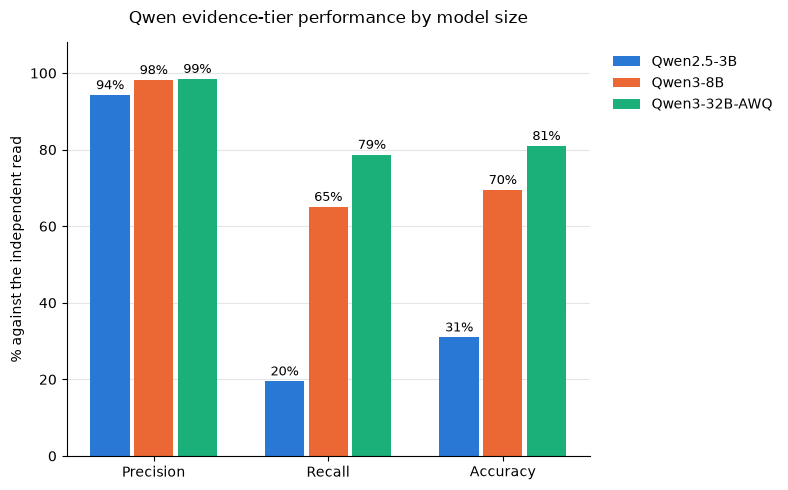

In [19]:
# QWEN MODEL SIZE VS. PERFORMANCE, SAME 200 PATTERNS AGAINST THE SAME INDEPENDENT-READ REFERENCE
def plot_qwen_size_comparison(reliability: pd.DataFrame, models: list[str], figsize: tuple[float, float] = (8, 5)) -> None:
    # fixed categorical order (smallest -> largest model), validated colorblind-safe adjacent pairs
    colors = {models[0]: "#2a78d6", models[1]: "#eb6834", models[2]: "#1baf7a"}
    metrics = ["precision", "recall", "accuracy"]
    width = 0.25

    fig, ax = plt.subplots(figsize=figsize)
    for i, model in enumerate(models):
        offsets = [x + (i - 1) * width for x in range(len(metrics))]
        values = [100 * reliability.loc[model, metric] for metric in metrics]
        bars = ax.bar(offsets, values, width=width * 0.9, label=model, color=colors[model])
        ax.bar_label(bars, fmt="%.0f%%", padding=2, fontsize=9)

    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels([metric.capitalize() for metric in metrics])
    ax.set_ylim(0, 108)
    ax.set_ylabel("% against the independent read")
    ax.set_title("Qwen evidence-tier performance by model size", pad=14)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, color="#e5e5e5", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.show()


plot_qwen_size_comparison(reliability, ["Qwen2.5-3B", "Qwen3-8B", "Qwen3-32B-AWQ"])

Model size matters more than a smaller sample suggested: Qwen2.5-3B claimed evidence for only 35/200 patterns (recall 19.5%, accuracy 31%) -- highly precise (94.3%) when it did commit, but too conservative to be usable as the evidence tier. Qwen3-8B closes most of that gap (recall 65.1%, accuracy 69.5%), but Qwen3-32B-AWQ adds a real further gain this time, not a marginal one: recall 78.7%, accuracy 81%, precision essentially unchanged across all three sizes (94.3% / 98.2% / 98.5%). An earlier version of this check, run on a 100-pattern sample, found Qwen3-8B and Qwen3-32B-AWQ nearly tied (74% vs. 72.8% recall) and concluded the 32B upgrade wasn't worth its GPU cost -- that conclusion did not hold at n=200: the 32B model catches a meaningfully larger share of the genuine evidence the smaller model misses, for no precision cost.

In [20]:
# HOW MUCH DID THE PRODUCTION Qwen3-32B SECOND PASS ACTUALLY RESOLVE, AT FULL-CRATE SCALE
pass2_counts = qwen3_32b_tally.sum(axis=0).to_dict()
pass2_total = sum(pass2_counts.values())
pass2_found = pass2_counts.get("llm", 0)

md(
    f"**Does the 200-pattern conclusion hold at full scale?** The pipeline did go on to run a real Qwen3-32B second pass over the crate's entire post-Qwen3-8B residual: of **{pass2_total:,}** values Qwen3-8B still couldn't ground, Qwen3-32B additionally grounded **{pass2_found:,} ({100 * pass2_found / pass2_total:.1f}%)**. "
    "That full-crate volume gain points the same direction as the 200-pattern precision/recall comparison above -- both show Qwen3-32B-AWQ catching a real, non-marginal share of what Qwen3-8B misses, not a rounding difference. "
    "The volume figure hasn't itself been checked against an independent read at full-crate scale, so it can't confirm the exact recall number, but it's consistent with the sample-based finding rather than in tension with it."
)

**Does the 200-pattern conclusion hold at full scale?** The pipeline did go on to run a real Qwen3-32B second pass over the crate's entire post-Qwen3-8B residual: of **134,878** values Qwen3-8B still couldn't ground, Qwen3-32B additionally grounded **55,181 (40.9%)**. That full-crate volume gain points the same direction as the 200-pattern precision/recall comparison above -- both show Qwen3-32B-AWQ catching a real, non-marginal share of what Qwen3-8B misses, not a rounding difference. The volume figure hasn't itself been checked against an independent read at full-crate scale, so it can't confirm the exact recall number, but it's consistent with the sample-based finding rather than in tension with it.

### LLM evidence review

An LLM (`Qwen3-8B`, served by vLLM) proposes evidence for values the deterministic cascade leaves unresolved. It is given the record's own raw text and asked for a direct statement or a specific, well-supported inference -- no outside world knowledge -- and every quote it proposes is independently checked against the source text before being trusted; a claim without a verified quote stays `not found`. This tier runs across the crate's full unresolved residual. Its precision and recall below come from the independent read above, over the same 200-pattern random sample.

In [21]:
# QWEN3-8B EVIDENCE TIER: PRECISION AND RECALL AGAINST THE INDEPENDENT READ
agreement_counts = unresolved_review["agreement"].value_counts()
match = int(agreement_counts.get("match", 0))
mismatch = int(agreement_counts.get("mismatch", 0))
not_found_correct = int(agreement_counts.get("not found (correct)", 0))
not_found_incorrect = int(agreement_counts.get("not found (incorrect)", 0))
precision, recall = match / (match + mismatch), match / (match + not_found_incorrect)

md(
    f"Of the tier's **{match + mismatch} grounded `found` claims** in this sample, the independent read agreed with **{match} -- precision = {100 * precision:.1f}%**. "
    f"Of the **{match + not_found_incorrect} cases with genuine evidence**, the tier caught **{match} -- recall = {100 * recall:.1f}%**. "
    f"The remaining **{not_found_correct}** both agree have no textual basis."
)

Of the tier's **112 grounded `found` claims** in this sample, the independent read agreed with **110 -- precision = 98.2%**. Of the **169 cases with genuine evidence**, the tier caught **110 -- recall = 65.1%**. The remaining **29** both agree have no textual basis.

The tier is highly precise when it does propose evidence: 98.2% of its grounded `found` claims held up against the independent read (only 2 false positives in 200, both requiring gene- or anatomy-specific knowledge beyond what the record states). Recall is the real limitation, and did not hold up at the smaller sample size first used to estimate it: an earlier, methodologically flawed n=100/n=200 check had put it anywhere from 41% to 73% depending on how the sample was built; this clean, single, unstratified 200-pattern random sample puts it at 65.1%. The dominant gap types are abbreviations, reworded phrasing, and values fused directly onto a construct or identifier with no separator -- wording and formatting variants the tier's current prompt tends to miss, not fabrications.

## Appendix: pipeline limitations

Trace-back measures whether an extracted value has supporting text in its source record. It does not determine whether the extracted value is biologically correct or whether the assigned ontology concept is the best concept. The examples below document errors that source-text matching cannot resolve.

### Ontology mapper accepts a coincidental short-symbol match instead of returning no match

In [22]:
# NITRIC OXIDE (CHEBI:16480): HOW MANY ASSIGNMENTS ARE A COINCIDENTAL "No" MATCH, NOT THE REAL COMPOUND
no_rows = trace_back_full[trace_back_full["assigned_term_id"] == "CHEBI:16480"]
legit_no_values = {"D-Ala-NO", "DETA/NO", "NO", "nitric oxide"}
no_collisions = no_rows[~no_rows["target_value"].isin(legit_no_values)]

md(
    f"Of **{len(no_rows)} rows** crate-wide assigned `CHEBI:16480` (nitric oxide), **{len(no_collisions)} ({100 * len(no_collisions) / len(no_rows):.0f}%)** "
    "are not nitric oxide at all -- they're free-text dietary/clinical notes extracted whole into the `drug` field "
    f"(e.g. `\"{no_collisions['target_value'].iloc[0]}\"`, `\"{no_collisions['target_value'].iloc[4]}\"`), which the ontology search then matched to ChEBI's own "
    "two-letter symbol for nitric oxide, `NO`, purely because they happen to start with the word \"No\". Every one of these rows is "
    f"`{'`/`'.join(sorted(no_collisions['strategy'].unique()))}` in this checker -- the sentence genuinely, verbatim appears in the raw record, so nothing "
    "here is a trace-back failure. Two separate pipeline mistakes compound: the LLM extracted a whole free-text note into a single-value field it doesn't "
    "belong in, and the ontology search then accepted a coincidental short-string match instead of returning no match at all."
)

Of **34 rows** crate-wide assigned `CHEBI:16480` (nitric oxide), **7 (21%)** are not nitric oxide at all -- they're free-text dietary/clinical notes extracted whole into the `drug` field (e.g. `"No casein, sugar, soy, corn, dyes"`, `"Mother GBS positive. Antibiotics during labor. Exclusively breastfed until 4 months. Will eat a wide range of food."`), which the ontology search then matched to ChEBI's own two-letter symbol for nitric oxide, `NO`, purely because they happen to start with the word "No". Every one of these rows is `exact` in this checker -- the sentence genuinely, verbatim appears in the raw record, so nothing here is a trace-back failure. Two separate pipeline mistakes compound: the LLM extracted a whole free-text note into a single-value field it doesn't belong in, and the ontology search then accepted a coincidental short-string match instead of returning no match at all.

### Correct extraction, wrong nearby term

In [23]:
# "bFGF" EXTRACTED CORRECTLY BUT MAPPED TO A DIFFERENT COMPOUND NAMED NEARBY IN THE SAME TEXT
bfgf_wrong = trace_back_full[(trace_back_full["target_value"] == "bFGF") & (trace_back_full["assigned_term_id"] == "CHEBI:86289")]

md(
    f"**{len(bfgf_wrong)} rows** extract `\"bFGF\"` -- found `{'`/`'.join(sorted(bfgf_wrong['strategy'].unique()))}` in the raw record every time -- but are "
    f"mapped to `{bfgf_wrong['assigned_term_id'].iloc[0]}` (**{bfgf_wrong['assigned_term_label'].iloc[0]}**), a different compound named right next to it "
    "in the same free-text attribute (\"...Chiron (CHIR), bFGF, DMH1 and SB-431542...\"). The ontology-mapping stage appears to have picked up a "
    "neighboring co-mentioned drug name instead of resolving the one it was actually asked to -- the same \"nearby but wrong term\" failure family as the "
    "nitric-oxide case above, but via co-occurrence rather than a short-string coincidence."
)

**8 rows** extract `"bFGF"` -- found `exact` in the raw record every time -- but are mapped to `CHEBI:86289` (**DMH1**), a different compound named right next to it in the same free-text attribute ("...Chiron (CHIR), bFGF, DMH1 and SB-431542..."). The ontology-mapping stage appears to have picked up a neighboring co-mentioned drug name instead of resolving the one it was actually asked to -- the same "nearby but wrong term" failure family as the nitric-oxide case above, but via co-occurrence rather than a short-string coincidence.

### Negation swallowed into a confidently-named, wrong compound

In [24]:
# "nodox" (= "no doxorubicin") FABRICATED INTO A CONFIDENT, WRONG DRUG NAME -- AND WHY IT CAN'T BE FOUND BY SEARCH ALONE
nodox_row = trace_back_full[(trace_back_full["accession"] == "SAMN17884731") & (trace_back_full["target_field"] == "drug")].iloc[0]
other_no_drugs = trace_back_full[
    (trace_back_full["target_field"] == "drug") & trace_back_full["target_value"].str.match(r"^[Nn]o[a-z]{5,}$", na=False) & (trace_back_full["target_value"] != nodox_row["target_value"])
]

md(
    f"`{nodox_row['accession']}`'s raw `treatment` attribute reads `\"nodox\"` -- shorthand for \"no doxorubicin,\" i.e. the sample was explicitly **not** "
    f"given the drug -- but the pipeline extracted `\"{nodox_row['target_value']}\"` as a drug name in its own right (correctly `{nodox_row['strategy']}` in "
    f"this checker -- that string never appears anywhere in the record), then mapped it to `{nodox_row['assigned_term_id']}` "
    f"(**{nodox_row['assigned_term_label']}**), a real but different, wrong compound. This inverts the record's actual meaning: the curated data now "
    "implies a dosing that never happened -- a more severe failure than an ordinary fabrication, since it asserts the opposite of the source. It also "
    f"can't be caught by an automated string search: **{other_no_drugs['target_value'].nunique()} other** legitimate drug names in this crate's `drug` field "
    f"happen to start with \"no\" (e.g. {', '.join(sorted(other_no_drugs['target_value'].str.lower().unique())[:4])}, ...), so a \"starts with no\" heuristic "
    "would swamp the one real case in false positives -- this one was only caught by hand."
)

`SAMN17884731`'s raw `treatment` attribute reads `"nodox"` -- shorthand for "no doxorubicin," i.e. the sample was explicitly **not** given the drug -- but the pipeline extracted `"nodoxorubicin"` as a drug name in its own right (correctly `not found` in this checker -- that string never appears anywhere in the record), then mapped it to `CHEBI:231680` (**aldoxorubicin**), a real but different, wrong compound. This inverts the record's actual meaning: the curated data now implies a dosing that never happened -- a more severe failure than an ordinary fabrication, since it asserts the opposite of the source. It also can't be caught by an automated string search: **36 other** legitimate drug names in this crate's `drug` field happen to start with "no" (e.g. nobiletin, nocodazol, nocodazole, nodakenin, ...), so a "starts with no" heuristic would swamp the one real case in false positives -- this one was only caught by hand.

### General fabrication rate, projected onto the full crate

In [25]:
# FABRICATION SHARE OF "NOT FOUND" ROWS (FROM THE REVIEWED SAMPLE ABOVE), PROJECTED ONTO THE FULL CRATE
no_evidence_rows = unresolved_review[unresolved_review["gap_type"] == "fabricated / no textual basis"]
n_no_evidence = len(no_evidence_rows)
total_not_found = int((trace_back_full["strategy"] == "not found").sum())
projected_fabricated = round(total_not_found * n_no_evidence / len(unresolved_review))
example_row = no_evidence_rows.iloc[0]

md(
    f"**{n_no_evidence}/{len(unresolved_review)}** of the reviewed sample above had no discernible textual basis anywhere in the raw record at all -- pure invention, not a wording or format variant any deterministic tier or the LLM evidence tier could ever bridge "
    f"(e.g. `{example_row['accession']}`'s `{example_row['target_field']}={example_row['target_value']}`, which the independent review found no supporting text for anywhere in the raw record). Scaled to the crate's full **{total_not_found:,} not-found rows**, that's an estimated "
    f"**~{projected_fabricated:,} extracted values** with no supporting text anywhere in their source record -- a pipeline-level (LLM extraction) issue, not something any amount of matching-tier work here could fix."
)

**7/200** of the reviewed sample above had no discernible textual basis anywhere in the raw record at all -- pure invention, not a wording or format variant any deterministic tier or the LLM evidence tier could ever bridge (e.g. `SAMN49864466`'s `disease=lung cancer`, which the independent review found no supporting text for anywhere in the raw record). Scaled to the crate's full **303,839 not-found rows**, that's an estimated **~10,634 extracted values** with no supporting text anywhere in their source record -- a pipeline-level (LLM extraction) issue, not something any amount of matching-tier work here could fix.

These four are illustrative, not exhaustive -- they're the concrete instances actually run into while building the checker above, surfaced here so they're visible to whoever owns the pipeline's ontology-mapping and LLM-extraction stages, rather than lost in ad hoc conversation.